In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import netCDF4 as nc
import xarray as xr
import scipy.io as sio
from datetime import datetime, timedelta

import sys
sys.path.append("/home/z5297792/UNSW-MRes/MRes/modules") 
from utils import axis_ratio_from_Q, tangential_velocity


In [2]:
def solo(l, VT, VN, core_thresh=30_000):
    l, VT, VN = map(np.asarray, (l, VT, VN))
    m = np.isfinite(l) & np.isfinite(VT) & np.isfinite(VN)
    l, VT, VN = l[m], VT[m], VN[m]
    if l.size < 4:
        return np.nan, np.nan, np.nan, np.full((2,2), np.nan), np.nan

    def root_near_mid(x, y):
        c = np.polyfit(x, y, 3)
        r = np.roots(c)
        r = r[np.isreal(r)].real
        if r.size == 0:
            return np.nan
        mid = x[x.size // 2]
        return r[np.argmin(np.abs(r - mid))]

    def tangent_fit(x, y, x0):
        c = np.polyfit(x, y, 3)
        slope = np.polyval(np.polyder(c), x0)
        intercept = np.polyval(c, x0) - slope * x0
        yhat = np.polyval(c, x)
        sst = np.sum((y - y.mean())**2)
        r2 = 1 - np.sum((y - yhat)**2)/sst if sst > 0 else 1.0
        return slope, intercept, r2

    x0 = root_near_mid(l, VN)
    if not np.isfinite(x0):
        return np.nan, np.nan, np.nan, np.full((2,2), np.nan), np.nan

    mask = np.abs(l - x0) <= core_thresh
    l, VT, VN = l[mask], VT[mask], VN[mask]

    c, b, r2VN = tangent_fit(l, VN, x0)   # VN ≈ c*l + b near x0
    if not np.isfinite(c) or c == 0:
        return np.nan, np.nan, np.nan, np.full((2,2), np.nan), np.nan

    a = np.polyval(np.polyfit(l, VT, 3), x0)

    l0 = -b / c
    r0 =  a / c
    w  = 2 * c

    Aq11 = Aq22 = w / 4
    AQ = np.array([[Aq11, 0.0], [0.0, Aq22]])
    detAQ = np.linalg.det(AQ)
    A = np.sign(Aq11) * np.sqrt(np.abs(detAQ)) if np.isfinite(detAQ) else np.nan
    Q = AQ / A if np.isfinite(A) and A != 0 else np.full((2,2), np.nan)

    return l0, r0, w, Q, A

def project_sadcp_to_transect(x, y, u, v):
    x, y, u, v = map(np.asarray, (x, y, u, v))
    msk = np.isfinite(x) & np.isfinite(y) & np.isfinite(u) & np.isfinite(v)
    x, y, u, v = x[msk], y[msk], u[msk], v[msk]
    n = x.size
    if n == 0:
        return pd.DataFrame(columns=["x","y","u","v","V_N","V_T","l"]), np.nan

    # best-fit line y = m x + c
    A = np.c_[x, np.ones(n)]
    m, c0 = np.linalg.lstsq(A, y, rcond=None)[0]

    # unit tangent along line and normal (right-hand)
    t = np.array([1.0, m]); t /= np.linalg.norm(t)
    nvec = np.array([-t[1], t[0]])

    p0 = np.array([x[0], y[0]])
    pts = np.c_[x, y]
    s = (pts - p0) @ t          # signed along-track coordinate

    idx = np.argsort(s)
    s, u, v = s[idx], u[idx], v[idx]

    s_new = np.linspace(s.min(), s.max(), n)
    u_new = np.interp(s_new, s, u)
    v_new = np.interp(s_new, s, v)

    pts_new = p0 + np.outer(s_new, t)
    x_new, y_new = pts_new[:, 0], pts_new[:, 1]

    VT = u_new*t[0] + v_new*t[1]
    VN = u_new*nvec[0] + v_new*nvec[1]

    df = pd.DataFrame({"x": x_new, "y": y_new, "u": u_new, "v": v_new, "V_N": VN, "V_T": VT})
    df["l"] = s_new - s_new.min()   # 0 at start, increasing along transect

    return df, m

def translate_solo_results(x_l_start, y_l_start, m, l0, r0):
    denom = np.sqrt(1 + m**2)
    x0 = (l0 - r0*m)/denom + x_l_start
    y0 = (l0*m + r0)/denom + y_l_start
    return x0, y0

def fit_psi_params(rho2, Qr, vt, A0=None, Rc0=None, plot=False, ax=None,
                   maxfev=10000, Rc_max=1e5, r2_flag=False,
                   rho_plot_max=None, n_curve=400):
    
    from scipy.optimize import curve_fit

    rho2 = np.asarray(rho2, float)
    Qr   = np.asarray(Qr, float)
    vt   = np.asarray(vt, float)

    m = np.isfinite(rho2) & np.isfinite(Qr) & np.isfinite(vt) & (rho2 >= 0) & (Qr != 0)
    if not np.any(m):
        return (np.nan, np.nan, np.nan, np.nan) if r2_flag else (np.nan, np.nan, np.nan)

    rho2 = rho2[m]; Qr = Qr[m]; vt = vt[m]

    # v*_t = v_t * (rho/Qr)
    rho = np.sqrt(rho2)
    vt = vt * (rho / Qr)

    def vt_model(rho2_, A, Rc):
        return 2.0 * A * np.sqrt(rho2_) * np.exp(-rho2_ / (Rc * Rc))

    # initial Rc0 from location of max |vt|
    i = np.nanargmax(np.abs(vt))
    rho_max = rho[i]
    if Rc0 is None:
        Rc0 = max(rho_max * np.sqrt(2.0), 1e-6)

    if A0 is None:
        denom = 2.0 * rho * np.exp(-rho2 / (Rc0 * Rc0))
        ok = np.abs(denom) > 0
        A0 = np.nanmedian(vt[ok] / denom[ok]) if np.any(ok) else 0.0
    if not np.isfinite(A0):
        A0 = 0.0

    try:
        popt, _ = curve_fit(
            vt_model, rho2, vt, p0=[A0, Rc0],
            bounds=([-np.inf, 1e-8], [np.inf, np.inf]),
            maxfev=maxfev
        )
        A_opt, Rc_opt = popt
    except Exception:
        A_opt, Rc_opt = A0, Rc0

    if (not np.isfinite(Rc_opt)) or (Rc_opt > Rc_max):
        A_opt, Rc_opt = A0, Rc0

    psi0_opt = -A_opt * Rc_opt**2

    vt_fit = vt_model(rho2, A_opt, Rc_opt)
    ss_res = np.sum((vt - vt_fit)**2)
    ss_tot = np.sum((vt - vt.mean())**2)
    r2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan

    if plot:
        if ax is None:
            _, ax = plt.subplots()

        if rho_plot_max is None:
            rho_plot_max = float(np.nanmax(rho)) if rho.size else Rc_opt

        r_grid = np.linspace(0.0, rho_plot_max, n_curve)
        vt_grid = vt_model(r_grid**2, A_opt, Rc_opt)

        ax.scatter(rho, np.abs(vt), s=20, marker='.', label='Observed')
        ax.plot(r_grid, np.abs(vt_grid), lw=3, label='Fit')
        ax.axvline(Rc_opt/np.sqrt(2), ls='--', lw=3, label=r'$\rho_{\max}$')

        ax.set_xlabel(r'$\rho$')
        ax.set_ylabel(r'$|v_t^\star|$')
        ax.set_title(f'A={A_opt:.4g}, Rc={Rc_opt:.4g}, psi0={psi0_opt:.4g}, R²={r2:.2f}')
        ax.legend()

    return (Rc_opt, psi0_opt, A_opt, r2) if r2_flag else (Rc_opt, psi0_opt, A_opt)


### SADCP Data

In [3]:
sad = sio.loadmat('/srv/scratch/z5297792/ESP_Paper_Data/sadcp_data_CCE_2023.mat', simplify_cells=True)

z = sad['z_sadcp']
ref = datetime(2000,1,1,12)
time = np.array([ref + timedelta(days=jd-2451545.0) for jd in sad['tim_sadcp']], dtype='datetime64[ns]')

df = pd.DataFrame({
    "Time": time,
    "Lon": sad['lon_sadcp'],
    "Lat": sad['lat_sadcp']
})

df = pd.concat([
    df,
    pd.DataFrame(sad['u_sadcp'], index=[f'u_{zv}' for zv in z]).T,
    pd.DataFrame(sad['v_sadcp'], index=[f'v_{zv}' for zv in z]).T
], axis=1)

df = df[df.Lat <= -37].reset_index(drop=True)

theta_mean, phi_mean = 154.3, -37.9
df["x"] = (df.Lon-theta_mean)*111000*np.cos(np.deg2rad(phi_mean))
df["y"] = (df.Lat-phi_mean)*111000

ds_sadcp = xr.Dataset(
    {"u": (("time","z"), df[[f"u_{zz}" for zz in z]].to_numpy()),
     "v": (("time","z"), df[[f"v_{zz}" for zz in z]].to_numpy())},
    coords={
        "time": df.Time.values,
        "z": z,
        "lon": ("time", df.Lon.values),
        "lat": ("time", df.Lat.values),
        "x": ("time", df.x.values),
        "y": ("time", df.y.values),
    }
)

# Transect slice
t0 = pd.Timestamp("2023-10-20 13:30:00")
dt = pd.Timedelta(days=0.5)
ds_sadcp = ds_sadcp.sel(time=(ds_sadcp.time >= t0-dt) & (ds_sadcp.time <= t0+dt)).sel(z=37, method="nearest")

ds_sadcp


<xarray.Dataset> Size: 5kB
Dimensions:  (time: 96)
Coordinates:
  * time     (time) datetime64[ns] 768B 2023-10-20T01:42:30.333327 ... 2023-1...
    z        uint16 2B 37
    lon      (time) float64 768B 153.2 153.2 153.2 153.3 ... 155.4 155.4 155.5
    lat      (time) float64 768B -37.87 -37.87 -37.87 ... -37.9 -37.9 -37.9
    x        (time) float64 768B -1.006e+05 -9.715e+04 ... 9.927e+04 1.023e+05
    y        (time) float64 768B 3.032e+03 3.017e+03 3.014e+03 ... -494.7 -411.1
Data variables:
    u        (time) float64 768B 0.3899 0.3461 0.3193 ... -0.09352 -0.1013
    v        (time) float64 768B 1.233 0.8805 0.795 ... -0.4728 -0.3191 -0.2972

### Satellite Data

In [4]:
ssh_path = '/srv/scratch/z5297792/ESP_Paper_Data/sat_data_IMOS_drifters.nc'
ds_nc = nc.Dataset(ssh_path)

lon, lat = ds_nc['LONGITUDE'][:].data, ds_nc['LATITUDE'][:].data
u, v = ds_nc['UCUR'][:].data, ds_nc['VCUR'][:].data

t = pd.Timestamp("1985-01-01 00:00:00", tz="UTC") + pd.to_timedelta(ds_nc['TIME'][:].data, "D")
t = pd.DatetimeIndex(t).tz_convert(None)

u, v = np.where(np.abs(u) < 4.9, u, np.nan), np.where(np.abs(v) < 4.9, v, np.nan)

ds = xr.Dataset(
    {"u": (("time","lat","lon"), u), "v": (("time","lat","lon"), v)},
    coords={"time": t, "lat": lat, "lon": lon},
)

theta_mean, phi_mean = np.float64(154.3), np.float64(-37.9)
lon2d, lat2d = np.meshgrid(lon, lat)
ds = ds.assign_coords(
    x=(("lat","lon"), (lon2d-theta_mean)*111000*np.cos(np.deg2rad(phi_mean))),
    y=(("lat","lon"), (lat2d-phi_mean)*111000),
)

t0, t1 = ds.time.to_index()[0], ds.time.to_index()[-1]
start = t0.normalize() + pd.Timedelta(hours=6) + pd.Timedelta(days=int(t0 > t0.normalize() + pd.Timedelta(hours=6)))
end   = t1.normalize() + pd.Timedelta(hours=6) - pd.Timedelta(days=int(t1 < t1.normalize() + pd.Timedelta(hours=6)))
t6am = pd.date_range(start, end, freq="1D")

ds_sat = ds.interp(time=t6am)

# Find land mask
land_mask = np.isnan(ds.u.isel(time=0)) & np.isnan(ds.v.isel(time=0))  # (lat, lon)
ds = ds.assign(land_mask=land_mask)
ds_sat = ds_sat.assign(land_mask=land_mask)

# # Time slice
ds_sat = ds_sat.sel(time=ds_sat.time <= np.datetime64('2024-01-27T06:00:00.000000000'))

# Transect time slice
ds_sat = ds_sat.sel(time=t0, method="nearest")

ds_sat


<xarray.Dataset> Size: 63kB
Dimensions:    (lat: 41, lon: 46)
Coordinates:
  * lat        (lat) float64 328B -42.0 -41.8 -41.6 -41.4 ... -34.4 -34.2 -34.0
  * lon        (lon) float64 368B 149.0 149.2 149.4 149.6 ... 157.6 157.8 158.0
    x          (lat, lon) float64 15kB -4.642e+05 -4.467e+05 ... 3.241e+05
    y          (lat, lon) float64 15kB -4.551e+05 -4.551e+05 ... 4.329e+05
    time       datetime64[ns] 8B 2023-10-19T06:00:00
Data variables:
    u          (lat, lon) float64 15kB -0.165 -0.2501 -0.3148 ... 0.2204 0.1816
    v          (lat, lon) float64 15kB -0.1421 -0.1373 ... -0.4873 -0.4257
    land_mask  (lat, lon) bool 2kB False False False False ... False False False

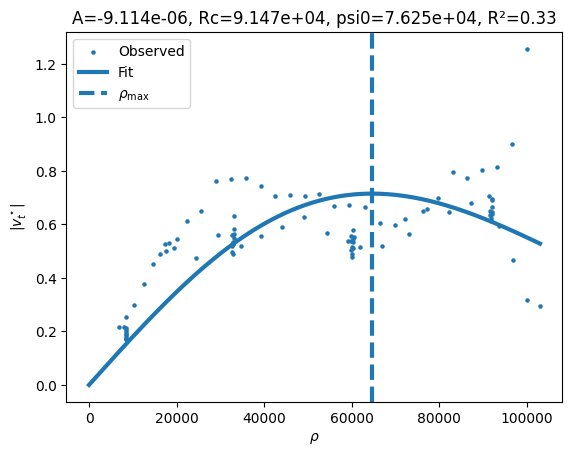

In [5]:
xi, yi, ui, vi = ds_sadcp.x.values, ds_sadcp.y.values, ds_sadcp.u.values, ds_sadcp.v.values

df_proj, moca_meta = project_sadcp_to_transect(xi, yi, ui, vi)
l0, r0, w, Q, A = solo(df_proj.l, df_proj.V_T, df_proj.V_N)
xc, yc = translate_solo_results(df_proj.iloc[0].x, df_proj.iloc[0].y, moca_meta, l0, r0)

dx = xi - xc
dy = yi - yc
rho2 = Q[0,0]*dx*dx + 2*Q[1,0]*dx*dy + Q[1,1]*dy*dy

rho_outer = 120_000
outer = rho2 <= rho_outer**2
xi_o, yi_o, ui_o, vi_o = xi[outer], yi[outer], ui[outer], vi[outer]
dx_o, dy_o, rho2_o = dx[outer], dy[outer], rho2[outer]

vt_o = tangential_velocity(xi_o, yi_o, ui_o, vi_o, xc, yc, Q)
Qr_o = np.sqrt((Q[0,0]*dx_o + Q[1,0]*dy_o)**2 + (Q[1,0]*dx_o + Q[1,1]*dy_o)**2)

sign_mask = (vt_o <= 0) if (A < 0) else (vt_o >= 0)
rho2_f, Qr_f, vt_f = rho2_o[sign_mask], Qr_o[sign_mask], vt_o[sign_mask]

Rc, psi0, A_opt = fit_psi_params(rho2_f, Qr_f, vt_f, A0=A, plot=True)
alpha = axis_ratio_from_Q(Q)

data = {'xc': [xc], 'yc': [yc], 'w': [w], 'Q': [Q], 'alpha': [alpha], 'A': [A],
        'Rc': [Rc], 'psi0': [psi0], 'A_opt': [A_opt], 'time': [ds_sadcp.time.mean()]}
data = pd.DataFrame(data).iloc[0]


In [18]:
x = np.linspace(-150_000, 150_000, 200)
y = np.linspace(-150_000, 150_000, 200)
X, Y = np.meshgrid(x, y, indexing="xy")   # U,V will be (y,x)

dx = X - data.xc
dy = Y - data.yc
q11, q12, q22 = data.Q[0,0], data.Q[0,1], data.Q[1,1]

rho2 = q11*dx*dx + 2*q12*dx*dy + q22*dy*dy
fac  = data.A_opt * np.exp(-rho2 / data.Rc**2)

U = -fac * (2*q12*dx + 2*q22*dy)
V =  fac * (2*q11*dx + 2*q12*dy)

ds_model = xr.Dataset(
    data_vars=dict(
        u=(("y","x"), U),
        v=(("y","x"), V),
    ),
    coords=dict(
        x=("x", x),
        y=("y", y),
        x2d=(("y","x"), X),
        y2d=(("y","x"), Y),
    ),
)
ds_model


<xarray.Dataset> Size: 1MB
Dimensions:  (y: 200, x: 200)
Coordinates:
  * x        (x) float64 2kB -1.5e+05 -1.485e+05 -1.47e+05 ... 1.485e+05 1.5e+05
  * y        (y) float64 2kB -1.5e+05 -1.485e+05 -1.47e+05 ... 1.485e+05 1.5e+05
    x2d      (y, x) float64 320kB -1.5e+05 -1.485e+05 ... 1.485e+05 1.5e+05
    y2d      (y, x) float64 320kB -1.5e+05 -1.5e+05 -1.5e+05 ... 1.5e+05 1.5e+05
Data variables:
    u        (y, x) float64 320kB -0.01428 -0.01506 -0.01588 ... 0.01172 0.0111
    v        (y, x) float64 320kB 0.01456 0.0152 0.01587 ... -0.01139 -0.0109

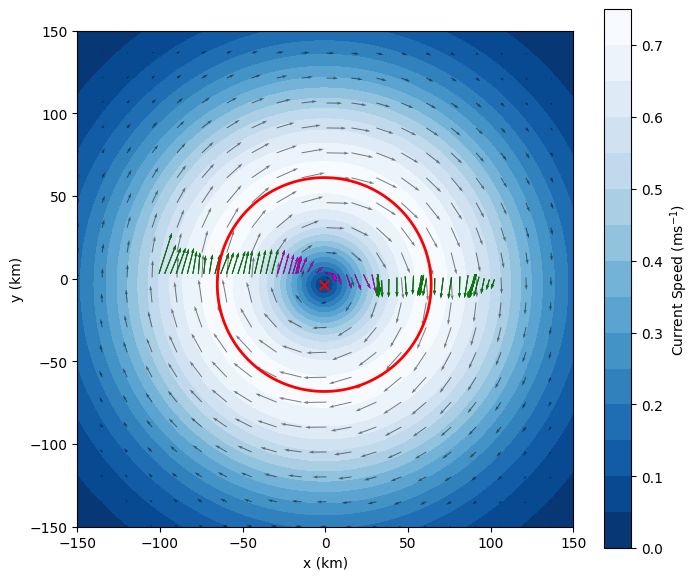

In [43]:
u = ds_model.u
v = ds_model.v
speed = np.hypot(u, v)

# 1D km coords for plotting
x = (ds_model.x / 1e3).values
y = (ds_model.y / 1e3).values

xmin, xmax = -150, 150
ymin, ymax = -150, 150

# 2D ROI mask (ny, nx)
Xkm, Ykm = np.meshgrid(x, y, indexing="xy")
roi = (Xkm >= xmin) & (Xkm <= xmax) & (Ykm >= ymin) & (Ykm <= ymax)

speed_m = speed.where(roi)

vmin = float(speed_m.min(skipna=True))
vmax = float(speed_m.max(skipna=True))
levels = np.arange(0, vmax+.05, .05)

fig, ax = plt.subplots(figsize=(8,7))

# field first (so vectors on top)
cf = ax.contourf(x, y, speed_m.values, levels=levels, cmap="Blues_r", vmin=vmin, vmax=vmax, zorder=-1)
fig.colorbar(cf, ax=ax, label=r"Current Speed (ms$^{-1}$)")

spac, scale = 10, 15
ax.quiver(x[::spac], y[::spac],
              u[::spac,::spac], v[::spac,::spac],
              scale=scale, alpha=.5, width=.002)

# SADCP vectors (x,y already metres -> convert to km; u,v are m/s)
ax.quiver(ds_sadcp.x.values/1e3, ds_sadcp.y.values/1e3,
          ds_sadcp.u.values, ds_sadcp.v.values,
          width=.002, scale=scale)

R = np.hypot(data.xc - ds_sadcp.x.values, data.yc - ds_sadcp.y.values)

core_mask  = R <= 30_000
outer_mask = (R > 30_000) & (R <= 120_000)

ax.quiver(ds_sadcp.x.values[core_mask]/1e3, ds_sadcp.y.values[core_mask]/1e3,
          ds_sadcp.u.values[core_mask], ds_sadcp.v.values[core_mask],
          width=.002, scale=scale, color='m', label='core data')

ax.quiver(ds_sadcp.x.values[outer_mask]/1e3, ds_sadcp.y.values[outer_mask]/1e3,
          ds_sadcp.u.values[outer_mask], ds_sadcp.v.values[outer_mask],
          width=.002, scale=scale, color='g', label='outer-core data') 

# center
ax.scatter(xc/1e3, yc/1e3, marker="x", color="r", s=50)

# ellipse contour: compute in metres, but evaluate on the km grid
Xm = Xkm * 1e3
Ym = Ykm * 1e3
dx = Xm - xc
dy = Ym - yc
rho2 = Q[0,0]*dx*dx + 2*Q[0,1]*dx*dy + Q[1,1]*dy*dy

ax.contour(x, y, rho2, levels=[(Rc**2)/2], colors="r", linewidths=2)

ax.set_aspect("equal", adjustable="box")
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_xlabel("x (km)")
ax.set_ylabel("y (km)")
plt.show()
